In [1]:
import pandas as pd
import numpy as np 
import torch
import os
import glob
import matplotlib.pyplot as plt 
from PIL import Image

Class 0: 200 ảnh
Class 1: 200 ảnh
Class 2: 200 ảnh
Class 3: 200 ảnh
Class 4: 200 ảnh
Class 5: 200 ảnh
Class 6: 200 ảnh
Class 7: 200 ảnh
Class 8: 200 ảnh
Class 9: 200 ảnh


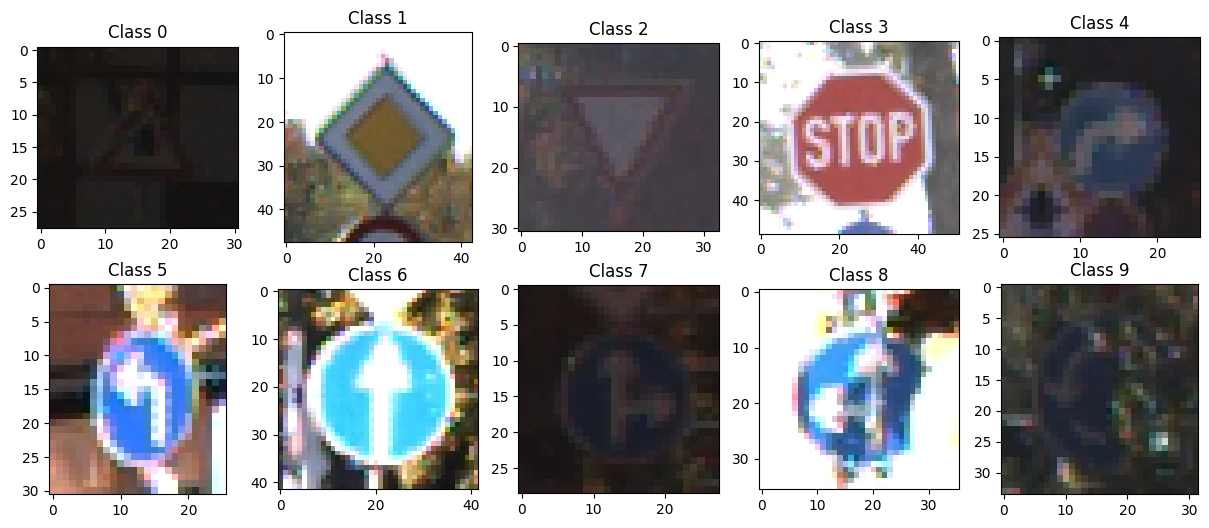

In [2]:
TRAIN_DIR ='../data/train'
TEST_DIR = '../data/test'

for cls in sorted(os.listdir(TRAIN_DIR)):        #dem so anh moi class
    n=len(os.listdir(os.path.join(TRAIN_DIR,cls)))
    print(f"Class {cls}: {n} ảnh")
# Xem thử một vài ảnh
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img_path = glob.glob(f"{TRAIN_DIR}/{i}/*.png")[0]
    ax.imshow(Image.open(img_path))
    ax.set_title(f"Class {i}")
plt.show()


In [3]:
import tensorflow as tf

def build_model():
    model = tf.keras.Sequential([
        # Block 1
        tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu', input_shape=(32,32,3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),      # → 16×16

        # Block 2
        tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),      # → 8×8

        # Block 3
        tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),      # → 4×4

        tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),   # → 2×2


        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(10, activation='softmax'),
    ])
    return model

model = build_model()
model.summary()   # ← kiểm tra tổng params < 200.000


d:\dut_ai\AIO_Code\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,882 (515.16 KB)

 Trainable params: 131,402 (513.29 KB)

 Non-trainable params: 480 (1.88 KB)

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,          # thêm mới
    shear_range=0.1,          # thêm mới
    brightness_range=[0.8, 1.2],  # thêm - thay đổi độ sáng
    horizontal_flip=False,   # biển báo không nên flip ngang
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(32, 32),
    batch_size=32,
    class_mode='sparse',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(32, 32),
    batch_size=32,
    class_mode='sparse',
    subset='validation'
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
    tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(train_gen, validation_data=val_gen, epochs=100, callbacks=callbacks)


Found 1600 images belonging to 10 classes.
Found 400 images belonging to 10 classes.
Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.2689 - loss: 2.3422

50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 387ms/step - accuracy: 0.3619 - loss: 1.8506 - val_accuracy: 0.1000 - val_loss: 2.4487 - learning_rate: 0.0010
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.5706 - loss: 1.1977 - val_accuracy: 0.1300 - val_loss: 2.6481 - learning_rate: 0.0010
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.6819 - loss: 0.8930 - val_accuracy: 0.1225 - val_loss: 3.2144 - learning_rate: 0.0010
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.7769 - loss: 0.6302 - val_accuracy: 0.2000 - val_loss: 3.5469 - learning_rate: 0.0010
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.8656 - loss: 0.3984 - val_accuracy: 0.1925 - val_loss: 3.5059 - learning_rate: 0.0010
Epoch 6/100
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8869 - loss: 0.3393

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9044 - loss: 0.3018 - val_accuracy: 0.3275 - val_loss: 2.3819 - learning_rate: 0.0010
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.9038 - loss: 0.2743 - val_accuracy: 0.3475 - val_loss: 2.4815 - learning_rate: 0.0010
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9305 - loss: 0.2188

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9306 - loss: 0.2158 - val_accuracy: 0.5825 - val_loss: 1.5063 - learning_rate: 0.0010
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9389 - loss: 0.1618

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9506 - loss: 0.1454 - val_accuracy: 0.5925 - val_loss: 1.3733 - learning_rate: 0.0010
Epoch 10/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9644 - loss: 0.1155 - val_accuracy: 0.6000 - val_loss: 1.5296 - learning_rate: 0.0010
Epoch 11/100
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9599 - loss: 0.1023

...

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.9956 - loss: 0.0184 - val_accuracy: 0.8700 - val_loss: 0.4921 - learning_rate: 5.0000e-04
Epoch 24/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9947 - loss: 0.0203

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.9900 - loss: 0.0288 - val_accuracy: 0.8900 - val_loss: 0.4415 - learning_rate: 5.0000e-04
Epoch 25/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.9944 - loss: 0.0201 - val_accuracy: 0.8825 - val_loss: 0.5026 - learning_rate: 5.0000e-04
Epoch 26/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.9956 - loss: 0.0161 - val_accuracy: 0.8500 - val_loss: 0.6746 - learning_rate: 5.0000e-04
Epoch 27/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.9944 - loss: 0.0178 - val_accuracy: 0.8575 - val_loss: 0.6097 - learning_rate: 5.0000e-04
Epoch 28/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9925 - loss: 0.0288 - val_accuracy: 0.8600 - val_loss: 0.5172 - learning_rate: 5.0000e-04
Epoch 29/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.9931 - loss: 0.0222 - val_accuracy: 0.8650 - val_loss: 0.5219 - learning_rate: 5.0000e-04
Epoch 30/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.9956

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.9962 - loss: 0.0107 - val_accuracy: 0.8825 - val_loss: 0.4142 - learning_rate: 2.5000e-04
Epoch 35/100
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9985 - loss: 0.0074

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9987 - loss: 0.0071 - val_accuracy: 0.9025 - val_loss: 0.4062 - learning_rate: 2.5000e-04
Epoch 36/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9962 - loss: 0.0102 - val_accuracy: 0.8675 - val_loss: 0.5193 - learning_rate: 2.5000e-04
Epoch 37/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9987 - loss: 0.0079 - val_accuracy: 0.9000 - val_loss: 0.4621 - learning_rate: 2.5000e-04
Epoch 38/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9987 - loss: 0.0097 - val_accuracy: 0.8875 - val_loss: 0.4978 - learning_rate: 2.5000e-04
Epoch 39/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9987 - loss: 0.0071 - val_accuracy: 0.8900 - val_loss: 0.4908 - learning_rate: 2.5000e-04
Epoch 40/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9975 - loss: 0.0096 - val_accuracy: 0.9000 - val_loss: 0.4401 - learning_rate: 2.5000e-04
Epoch 41/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9969

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9994 - loss: 0.0054 - val_accuracy: 0.9100 - val_loss: 0.3662 - learning_rate: 1.2500e-04
Epoch 46/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.9981 - loss: 0.0065 - val_accuracy: 0.8950 - val_loss: 0.4556 - learning_rate: 1.2500e-04
Epoch 47/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.9981 - loss: 0.0070 - val_accuracy: 0.8600 - val_loss: 0.5105 - learning_rate: 1.2500e-04
Epoch 48/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9994 - loss: 0.0051 - val_accuracy: 0.8975 - val_loss: 0.4517 - learning_rate: 1.2500e-04
Epoch 49/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9975 - loss: 0.0065 - val_accuracy: 0.8900 - val_loss: 0.4706 - learning_rate: 1.2500e-04
Epoch 50/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.9975 - loss: 0.0083 - val_accuracy: 0.8775 - val_loss: 0.4919 - learning_rate: 1.2500e-04
Epoch 51/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.9994

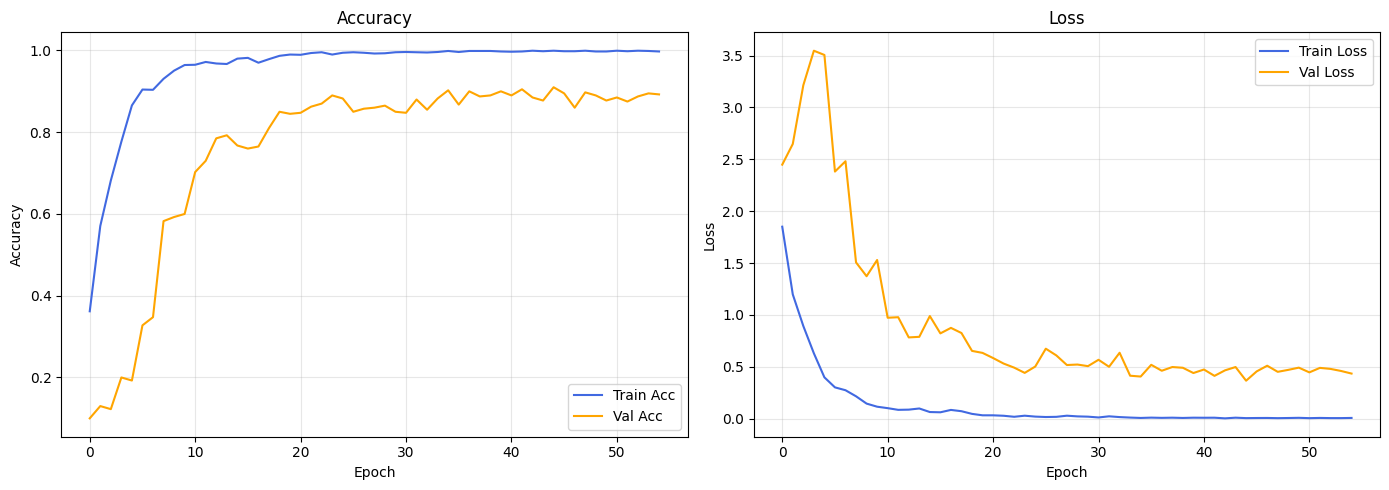

Best val_accuracy: 0.9100 tại Epoch 45


In [5]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train Acc', color='royalblue')
ax1.plot(history.history['val_accuracy'], label='Val Acc',   color='orange')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'],     label='Train Loss', color='royalblue')
ax2.plot(history.history['val_loss'], label='Val Loss',   color='orange')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# In kết quả tốt nhất
best_epoch = history.history['val_accuracy'].index(max(history.history['val_accuracy'])) + 1
best_val   = max(history.history['val_accuracy'])
print(f"Best val_accuracy: {best_val:.4f} tại Epoch {best_epoch}")


In [6]:
from tensorflow.keras.models import load_model
# Load best model đã save
best_model = load_model('best_model.h5')
# Tạo representative dataset cho int8 quantization
def representative_dataset():
    datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
    gen = datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(32, 32),
        batch_size=1,
        shuffle=False
    )
    for i in range(200):   # dùng 200 ảnh để calibrate
        img, _ = next(gen)
        yield [img.astype(np.float32)]
# Convert sang TFLite int8
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8
tflite_model = converter.convert()
with open('model_int8.tflite', 'wb') as f:
    f.write(tflite_model)
print(f'TFLite model size: {len(tflite_model)/1024:.1f} KB')
print('Saved: model_int8.tflite')

INFO:tensorflow:Assets written to: C:\Users\khacb\AppData\Local\Temp\tmpx20wjw64\assets


INFO:tensorflow:Assets written to: C:\Users\khacb\AppData\Local\Temp\tmpx20wjw64\assets


Saved artifact at 'C:\Users\khacb\AppData\Local\Temp\tmpx20wjw64'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2058406458000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2058406460880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2058406459728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2058403602576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2058406460496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2058406458192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2058406461264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2058403602960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2058403604112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2058403599888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2058403

d:\dut_ai\AIO_Code\venv\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Found 2000 images belonging to 10 classes.
TFLite model size: 146.1 KB
Saved: model_int8.tflite


In [7]:
# Load TFLite interpreter
interpreter = tf.lite.Interpreter(model_path='model_int8.tflite')
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()
# Lấy scale/zero_point để quantize input
in_scale, in_zero   = input_details[0]['quantization']
out_scale, out_zero = output_details[0]['quantization']
def predict_tflite(img_path):
    img = Image.open(img_path).convert('RGB').resize((32, 32))
    x   = np.array(img, dtype=np.float32) / 255.0
    x_q = np.round(x / in_scale + in_zero).astype(np.int8)
    x_q = x_q[np.newaxis, ...]   # (1, 32, 32, 3)
    interpreter.set_tensor(input_details[0]['index'], x_q)
    interpreter.invoke()
    out_q = interpreter.get_tensor(output_details[0]['index'])[0]
    out_f = (out_q.astype(np.float32) - out_zero) * out_scale
    return int(np.argmax(out_f))
# Predict toàn bộ test set
test_images = sorted(glob.glob(f'{TEST_DIR}/*.png') + glob.glob(f'{TEST_DIR}/*.jpg'))
results = []
for img_path in test_images:
    img_id = os.path.splitext(os.path.basename(img_path))[0]
    label  = predict_tflite(img_path)
    results.append({'Id': img_id, 'Label': label})
df = pd.DataFrame(results)
df.to_csv('submission.csv', index=False)
print(f'Done! {len(df)} predictions saved to submission.csv')
df.head(10)

d:\dut_ai\AIO_Code\venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Done! 1000 predictions saved to submission.csv


,Id,Label
0,00000,4
1,00007,2
2,00012,2
3,00014,5
4,00022,1
5,00025,4
6,00029,2
7,00030,7
8,00032,2
9,00043,2
